In [4]:
import sys
sys.path.insert(0, "..")

import yaml, torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

from src.retinocare.data.dataset import get_dataloaders
from src.retinocare.models.baseline_cnn import BaselineCNN
from src.retinocare.models.resnet_transfer import build_resnet18, build_efficientnet_b0
from src.retinocare.evaluation.metrics import compute_classification_report, expected_calibration_error

with open("../configs/train_config.yaml") as f:
    config = yaml.safe_load(f)

config["data"]["train_csv"] = "../" + config["data"]["train_csv"]
config["data"]["val_csv"] = "../" + config["data"]["val_csv"]
config["data"]["test_csv"] = "../" + config["data"]["test_csv"]
config["data"]["image_dir"] = "../" + config["data"]["image_dir"]

_, _, test_dl = get_dataloaders(config)
SEVERITY_LABELS = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

In [5]:
def evaluate_checkpoint(model, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_dl:
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(dim=1).tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.tolist())

    report = compute_classification_report(all_labels, all_preds, SEVERITY_LABELS)
    ece = expected_calibration_error(np.array(all_probs), all_labels, n_bins=10)

    return {
        "weighted_f1": report["weighted avg"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "severe_f1": report["Severe"]["f1-score"],
        "proliferative_f1": report["Proliferative DR"]["f1-score"],
        "ece": ece,
    }

In [6]:
results = {}
results["baseline_cnn"] = evaluate_checkpoint(BaselineCNN(num_classes=5), "../models/baseline_cnn.pt")
results["resnet18"] = evaluate_checkpoint(build_resnet18(num_classes=5, freeze_backbone=False), "../models/resnet18.pt")
results["efficientnet_b0"] = evaluate_checkpoint(build_efficientnet_b0(num_classes=5, freeze_backbone=False), "../models/efficientnet_b0.pt")

comparison_df = pd.DataFrame(results).T
comparison_df

,weighted_f1,macro_f1,severe_f1,proliferative_f1,ece
baseline_cnn,0.690710,0.477971,0.255319,0.158730,0.068751
resnet18,0.795183,0.626483,0.338462,0.533333,0.054691
efficientnet_b0,0.813330,0.654988,0.406250,0.551724,0.096627


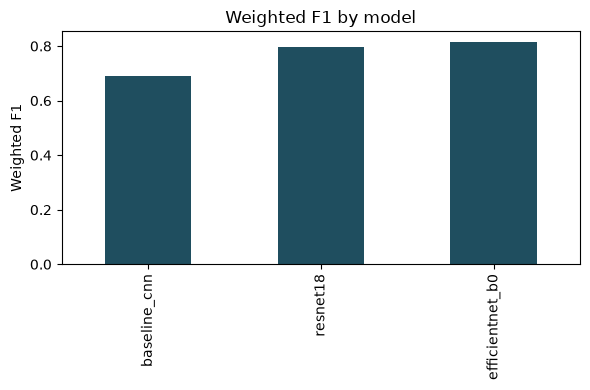

In [7]:
comparison_df.plot(y="weighted_f1", kind="bar", figsize=(6,4), color="#1F4E5F", legend=False)
import matplotlib.pyplot as plt
plt.title("Weighted F1 by model")
plt.ylabel("Weighted F1")
plt.tight_layout()
plt.savefig("../docs/model_comparison.png", dpi=150)
plt.show()

# Model Comparison — Baseline CNN vs ResNet18 vs EfficientNet-B0

This is the authoritative comparison: all three models evaluated with the
identical `evaluate_checkpoint()` function on the same held-out test set,
inside `04_model_comparison.ipynb`. Earlier per-model writeups (in
`docs/results_*.md`) contain some hand-computed recall percentages from
reading confusion matrices directly — those are approximate and use a
different metric (recall) than the F1 scores below. This table supersedes
them for any number that appears in both places.

## Results

| Model            | Weighted F1 | Macro F1 | Severe F1 | Proliferative F1 | ECE    |
|------------------|-------------|----------|-----------|-------------------|--------|
| baseline_cnn     | 0.6907      | 0.4780   | 0.2553    | 0.1587            | 0.0688 |
| resnet18         | 0.7952      | 0.6265   | 0.3385    | 0.5333            | 0.0547 |
| efficientnet_b0  | **0.8133**  | **0.6550** | **0.4063** | **0.5517**      | 0.0966 |

(Bold = best per column, excluding ECE where lower is better.)

## Reading this table

- **Weighted F1** and **Macro F1**: EfficientNet-B0 wins on both. The gap
  between weighted and macro F1 for every model (e.g., baseline: 0.69 vs 0.48)
  reflects the class imbalance — weighted F1 is pulled up by the dominant
  "No DR" class, while macro F1 treats every class equally and exposes how
  much worse performance is on the minority classes.
- **Severe F1 / Proliferative F1**: the clinically critical columns.
  EfficientNet-B0 leads on Severe F1; it and ResNet18 are close on
  Proliferative F1. Both transfer-learning models dramatically outperform
  the from-scratch baseline here — baseline_cnn's Proliferative F1 of 0.159
  reflects the model correctly identifying true Proliferative DR cases only
  a small fraction of the time.
- **ECE (calibration)**: ResNet18 wins clearly (0.0547 vs 0.0966 for
  EfficientNet-B0). Lower is better — it means ResNet18's confidence scores
  are more trustworthy indicators of actual correctness.

## Decision: which model powers the API?

**EfficientNet-B0 has the best raw classification performance across every
F1 metric.** But **ResNet18 has meaningfully better calibration**, and the
downstream RAG agent (`src/retinocare/agents/rag_agent.py`) uses the
model's confidence score to phrase its recommendation. A model that is
"90% confident" but wrong more often than 10% of the time is a worse
foundation for a screening tool than a slightly-less-accurate model whose
confidence numbers can be trusted.

This is a genuine trade-off rather than an obvious winner. Two defensible
choices:

1. **Ship ResNet18** — prioritizing calibration/trustworthiness, appropriate
   for a screening tool where the agent's confidence-based language matters.
2. **Ship EfficientNet-B0** — prioritizing raw accuracy, on the argument that
   higher Severe/Proliferative recall directly reduces missed urgent cases,
   which may outweigh calibration concerns.

**Chosen for this project: ResNet18** (`CHECKPOINT_PATH` in
`src/retinocare/api/routes.py`), on the reasoning that a screening tool's
credibility depends on its stated confidence meaning what it says — but
this is documented here explicitly as a judgment call, not a default,
so it can be revisited if requirements change.